In [1]:
import os
from dotenv import load_dotenv

load_dotenv()  # Load the base directory
BASE_DIR = os.getenv("BASE_DIR")
print(f"Base directory: {BASE_DIR}")


Base directory: /home/vijay/Documents/DiskANN-UofT


In [3]:
import os
import subprocess 
from pathlib import Path


def create_build(project_root, build_subdir="script_output", type="Release", tracking=True):
    # Define the build directory (inside `build/`)
    build_dir = os.path.join(project_root, "build", build_subdir)

    # Ensure build directory exists
    os.makedirs(build_dir, exist_ok=True)

    os.chdir(build_dir)

    # Run CMake configuration
    cmake_command = [
        "cmake",
        f"-DCMAKE_BUILD_TYPE={type}",
        f"-DTRACKING_ENABLED={'ON' if tracking else 'OFF'}",
        project_root
    ]
    subprocess.run(cmake_command, check=True)

    print("\n\nRunning make...")

    # Run Make inside the build directory
    make_command = ["make", "-j"]
    subprocess.run(make_command, check=True)

    print(f"Build completed successfully! Build artifacts are in {build_dir}")

    return build_dir


parent_dir = BASE_DIR

print("BASE directory:", parent_dir)

tracking = True

build_output = create_build(parent_dir, tracking=tracking)

BASE directory: /home/vijay/Documents/DiskANN-UofT
-- Tracking code is: ON
-- Found Boost: /usr/lib/x86_64-linux-gnu/cmake/Boost-1.83.0/BoostConfig.cmake (found version "1.83.0") found components: program_options 
-- Found Boost: /usr/lib/x86_64-linux-gnu/cmake/Boost-1.83.0/BoostConfig.cmake (found version "1.83.0") found components: program_options serialization 
-- Setting up `make format` and `make checkformat`
-- Configuring done (0.0s)
-- Generating done (0.1s)
-- Build files have been written to: /home/vijay/Documents/DiskANN-UofT/build/script_output


Running make...
[  7%] Built target fvecs_to_bvecs
[  6%] Built target tsv_to_bin
[  7%] Built target simulate_aggregate_recall
[  7%] Built target ivecs_to_bin
[  8%] Built target bin_to_tsv
[ 10%] Built target float_bin_to_int8
[ 11%] Built target fvecs_to_bin


status/home/vijay/Documents/DiskANN-UofT/apps/build_disk_index.cpp/home/vijay/Documents/DiskANN-UofT/apps/build_memory_index.cpp/home/vijay/Documents/DiskANN-UofT/apps/build_stitched_index.cpp/home/vijay/Documents/DiskANN-UofT/apps/range_search_disk_index.cpp/home/vijay/Documents/DiskANN-UofT/apps/restapi/client.cpp/home/vijay/Documents/DiskANN-UofT/apps/restapi/inmem_server.cpp/home/vijay/Documents/DiskANN-UofT/apps/restapi/main.cpp/home/vijay/Documents/DiskANN-UofT/apps/restapi/multiple_ssdindex_server.cpp/home/vijay/Documents/DiskANN-UofT/apps/restapi/ssd_server.cpp/home/vijay/Documents/DiskANN-UofT/apps/search_disk_index.cpp/home/vijay/Documents/DiskANN-UofT/apps/search_memory_index.cpp/home/vijay/Documents/DiskANN-UofT/apps/test_insert_deletes_consolidate.cpp/home/vijay/Documents/DiskANN-UofT/apps/test_streaming_scenario.cpp/home/vijay/Documents/DiskANN-UofT/apps/tracking/data_extractor.cpp/home/vijay/Documents/DiskANN-UofT/apps/utils/bin_to_fvecs.cpp/home/vijay/Documents/DiskANN-

[ 32%] Built target diskann_s
[ 54%] Built target diskann
[ 57%] Built target int8_to_float
[ 57%] Built target int8_to_float_scale
[ 61%] Built target uint8_to_float
[ 61%] Built target build_memory_index
[ 65%] Built target test_insert_deletes_consolidate
[ 65%] Built target rand_data_gen
[ 66%] Built target search_disk_index
[ 68%] Built target search_memory_index
[ 73%] Built target vector_analysis
[ 73%] Built target build_stitched_index
[ 73%] Built target count_bfs_levels
[ 75%] Built target build_disk_index
[ 77%] Built target test_streaming_scenario
[ 79%] Built target uint32_to_uint8
[ 81%] Built target range_search_disk_index
[ 83%] Built target gen_random_slice
[ 84%] Built target data_extractor
[ 87%] Built target calculate_recall
[ 87%] Built target compute_groundtruth_for_filters
[ 89%] Built target compute_groundtruth
[ 90%] Built target generate_pq
[ 94%] Built target create_disk_layout
[ 94%] Built target merge_shards
[ 96%] Built target partition_data
[ 97%] Built ta

In [4]:

import urllib.request
import tarfile

def download_sift(base_dir, apps_dir):
    tar_file_path = os.path.join(base_dir, "sift.tar.gz")
    extracted_folder = os.path.join(base_dir, "sift")

    sift_learn_fvecs = os.path.join(extracted_folder, "sift_learn.fvecs")
    sift_query_fvecs = os.path.join(extracted_folder, "sift_query.fvecs")

    sift_learn_fbin = os.path.join(extracted_folder, "sift_learn.fbin")
    sift_query_fbin = os.path.join(extracted_folder, "sift_query.fbin")

    util_dir = os.path.join(apps_dir, 'utils')

    # Ensure the directory exists
    os.makedirs(base_dir, exist_ok=True)

    # Check if the dataset is already extracted
    if not os.path.exists(extracted_folder):
        print("Dataset not found. Downloading...")

        # Download the file if not present
        if not os.path.exists(tar_file_path):
            url = "ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz"
            print(f"Downloading {url} ...")
            urllib.request.urlretrieve(url, tar_file_path)
            print("Download complete!")

        # Extract the tar.gz file
        print("Extracting dataset...")
        with tarfile.open(tar_file_path, "r:gz") as tar:
            tar.extractall(base_dir)
        print("Extraction complete!")

    else:
        print("Dataset already exists. Skipping download and extraction.")

    # Convert .fvecs to .fbin if necessary
    if os.path.exists(sift_learn_fvecs) and not os.path.exists(sift_learn_fbin):
        print("Converting sift_learn.fvecs to sift_learn.fbin...")
        subprocess.run([os.path.join(util_dir, "fvecs_to_bin"), "float", sift_learn_fvecs, sift_learn_fbin], check=True)
        print("Conversion complete!")

    if os.path.exists(sift_query_fvecs) and not os.path.exists(sift_query_fbin):
        print("Converting sift_query.fvecs to sift_query.fbin...")
        subprocess.run([os.path.join(util_dir, "fvecs_to_bin"), "float", sift_query_fvecs, sift_query_fbin], check=True)
        print("Conversion complete!")

    print("SIFT dataset is ready.")



build_dir = os.path.join(parent_dir, "build")
data_folder = os.path.join(build_dir, "data")
apps_dir = os.path.join(build_output, "apps")

os.makedirs(data_folder, exist_ok=True)
download_sift(data_folder, apps_dir)

sift_folder = os.path.join(data_folder, 'sift')


Dataset already exists. Skipping download and extraction.
SIFT dataset is ready.


In [12]:
# Paths to executables
compute_groundtruth = os.path.join(apps_dir, "utils/compute_groundtruth")
build_memory_index = os.path.join(apps_dir, "build_memory_index")
search_memory_index = os.path.join(apps_dir, "search_memory_index")

query_file_name = "sift_query.fbin"
base_file_name = "sift_learn.fbin"
gt_k = 100

# Paths to dataset files
base_file = os.path.join(sift_folder, base_file_name)
query_file = os.path.join(sift_folder, query_file_name)
gt_file = os.path.join(sift_folder, query_file+ f".gt_{str(gt_k)}")

if not os.path.exists(gt_file):
    # Step 1: Compute ground truth
    cmd1 = [
        compute_groundtruth,
        "--data_type", "float",
        "--dist_fn", "l2",
        "--base_file", base_file,
        "--query_file", query_file,
        "--gt_file", gt_file,
        "--K", str(gt_k)
    ]

    result = subprocess.run(cmd1, stdout=None, stderr=None, text=True)
    if result.returncode != 0:
        print(f"Error computing ground truth: {result.stderr}")
        exit(1)
else:
    print("Ground truth file already exists, skipping gt calculation.")

l_base = [10, 20, 30, 40, 50, 100]

print_out = False

experiments = [
    {
        "ls":l_base,
        "alpha": 1.2,
        "r":32,
        "l_build":50
    },
    # {
    #     "ls":l_base,
    #     "alpha": 1.2,
    #     "r":64,
    #     "l_build":50
    # },
    # {
    #     "ls":l_base,
    #     "alpha": 1.1,
    #     "r":32,
    #     "l_build":50
    # },
    # {
    #     "ls":l_base,
    #     "alpha": 1.1,
    #     "r":64,
    #     "l_build":50
    # },
]


Ground truth file already exists, skipping gt calculation.


In [13]:
import re

def run_and_parse_output(cmd, print_out=False):
    total_nodes = 0
    total_out_edges = 0
    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, bufsize=1)

    output_lines = []
    graph_pattern = re.compile(
        r"Index has\s+(\d+)\s+nodes\s+and\s+(\d+)\s+out-edges"
    )

    for line in iter(process.stdout.readline, ''):
        if print_out:
            print(line, end='')  # Print in real-time
        output_lines.append(line.strip())  # Store for later parsing
        graph_match = graph_pattern.search(line)
        if graph_match:
            total_nodes = int(graph_match.group(1))
            total_out_edges = int(graph_match.group(2))




    process.stdout.close()
    process.wait()

    if process.returncode != 0:
        print("Error running command:", process.stderr.read())
        return None

    # Parse output after printing
    data = []
    pattern = re.compile(r"\s*(\d+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)")

    for line in output_lines:
        match = pattern.match(line)
        if match:
            data.append([float(match.group(i)) for i in range(1, 7)])  # Convert values to float

    if not data:
        print("No data extracted.")
        return []

    # columns = ["Ls", "QPS", "Avg dist cmps", "Mean Latency (mus)", "99.9 Latency", "Recall@10"]
    return data, total_nodes, total_out_edges

def run_data_extractor(output_folder, apps_folder):
    raw_edges_file = os.path.join(output_folder, "res_raw_edges.bin")
    data_extractor = os.path.join(apps_folder, "tracking", "data_extractor")

    os.makedirs(output_folder, exist_ok=True)

    extractor = [
        data_extractor,
        raw_edges_file,
        os.path.join(output_folder, 'res'),
        "latest_dist",
        "hop_dist",
        "distance_dist",
        "exact_conv",
        "edge_dist"
    ]

    result = subprocess.run(extractor, stdout=None, stderr=None, text=True)
    if result.returncode != 0:
        print(f"Error in data extraction: {result.stderr}")
        return False


import json
import matplotlib.pyplot as plt
import os

def load_data(json_file):
    """
    Load data from a JSON file and return the parsed object.
    """
    with open(json_file, 'r') as f:
        return json.load(f)

def plot_generic_distribution(
        ax,
        data,
        x_parser=int,
        y_parser=float,
        plot_type='line',   # or 'scatter'
        x_label='X',
        y_label='Y',
        title='',
        x_log=False,
        y_log=False,
        sort_x=False,
        marker='o',
        alpha=0.7
):
    """
    A generic plotting function that can produce line or scatter plots
    from a dictionary-of-dictionaries. Each sub-dictionary is plotted
    as a separate series (labeled by its key).
    """
    for test_name, distribution in data.items():
        # distribution is typically a dict of { x_str: y_str }
        # We parse them using x_parser/y_parser
        x_vals = [x_parser(k) for k in distribution.keys()]
        y_vals = [y_parser(v) for v in distribution.values()]

        # Optionally sort on x (useful if the x-values are not inherently sorted)
        if sort_x:
            # zip them together, sort by x, then unzip
            xy_sorted = sorted(zip(x_vals, y_vals), key=lambda tup: tup[0])
            x_vals, y_vals = zip(*xy_sorted)

        if plot_type == 'line':
            ax.plot(x_vals, y_vals, marker=marker, linestyle='-', label=test_name)
        else:
            ax.scatter(x_vals, y_vals, marker=marker, alpha=alpha, label=test_name)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if x_log:
        ax.set_xscale('log')
    if y_log:
        ax.set_yscale('log')
    if title:
        ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

def plot_graphs(data_folder, file_prefix):
    """
    Dynamically loads JSON data files matching the given prefix and plots them.
    """
    # Define possible suffixes and their plotting configurations
    file_configurations = {
        "_exact_conv.json":          (float, int, 'line', "Proportion of nodes visited until best K nodes were found", "Number of queries", "Convergence Step Distribution", False, True, True),
        "_distance_dist.json": (int, float, 'scatter', "Step in Query (Node Visited)", "Average Distance", "Average Distance per Step", False, False, False),
        "_edge_dist.json":          (int, int, 'scatter', "Edge Count Distribution", "Number of Edges", "Count", False, False, True),
        "_edge_visits.json":          (int, int, 'scatter', "Edge Count Rank", "Number of Edges", "Edge Exploration Distribution", True, True, False),
        "_edge_utilization.json":     (int, float, 'scatter', "Time Step", "Edge Utilization", "Edge Utilization Over Time", False, False, False),
        "_hop_dist.json":     (int, int, 'scatter', "Number of edges used", "Number of queries", "Edge Exploration Distribution", False, False, False),
        "_latest_dist.json":  (float, int, 'line', "Proportion of nodes visited until lowest distance was found", "Number of queries", "Convergence Step Distribution", False, True, True),
        "_steps_distribution.json":   (int, int, 'line', "Number of Steps Taken to Converge", "Number of Queries", "Convergence Step Distribution", False, True, False),
    }

    # Find existing files
    available_files = {}
    for suffix in file_configurations.keys():
        file_path = os.path.join(data_folder, file_prefix + suffix)
        if os.path.exists(file_path):
            available_files[suffix] = file_path
            print(f"Found {file_path}")

    if not available_files:
        print("No matching files found.")
        return

    # Set up subplots dynamically based on available files
    num_plots = len(available_files)
    num_cols = 2  # Keep a two-column layout
    num_rows = (num_plots + num_cols - 1) // num_cols  # Round up
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(14, 5 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterate through found files and plot
    for idx, (suffix, file_path) in enumerate(available_files.items()):
        data = load_data(file_path)
        if data is None:
            continue

        x_parser, y_parser, plot_type, x_label, y_label, title, x_log, y_log, sort_x = file_configurations[suffix]
        plot_generic_distribution(
            ax=axes[idx],
            data=data,
            x_parser=x_parser,
            y_parser=y_parser,
            plot_type=plot_type,
            x_label=x_label,
            y_label=y_label,
            title=title,
            x_log=x_log,
            y_log=y_log,
            sort_x=sort_x
        )

    # Hide unused subplots if any
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()




Alpha: 1.2, R: 32
All steps completed successfully. 81.700% edges used
  22665.53 QPS, for L : 10.0
  15101.40 QPS, for L : 20.0
  11360.91 QPS, for L : 30.0
   9024.60 QPS, for L : 40.0
   7535.04 QPS, for L : 50.0
   4462.52 QPS, for L : 100.0
2614394 Total Edges in Graph
JSON written to /home/vijay/Documents/DiskANN-UofT/build/data/sift/r32-a1.2/res_latest_dist.json
JSON written to /home/vijay/Documents/DiskANN-UofT/build/data/sift/r32-a1.2/res_hop_dist.json
JSON written to /home/vijay/Documents/DiskANN-UofT/build/data/sift/r32-a1.2/res_distance_dist.json
JSON written to /home/vijay/Documents/DiskANN-UofT/build/data/sift/r32-a1.2/res_exact_conv.json
JSON written to /home/vijay/Documents/DiskANN-UofT/build/data/sift/r32-a1.2/res_edge_dist.json
Found /home/vijay/Documents/DiskANN-UofT/build/data/sift/r32-a1.2/res_exact_conv.json
Found /home/vijay/Documents/DiskANN-UofT/build/data/sift/r32-a1.2/res_distance_dist.json
Found /home/vijay/Documents/DiskANN-UofT/build/data/sift/r32-a1.2/r

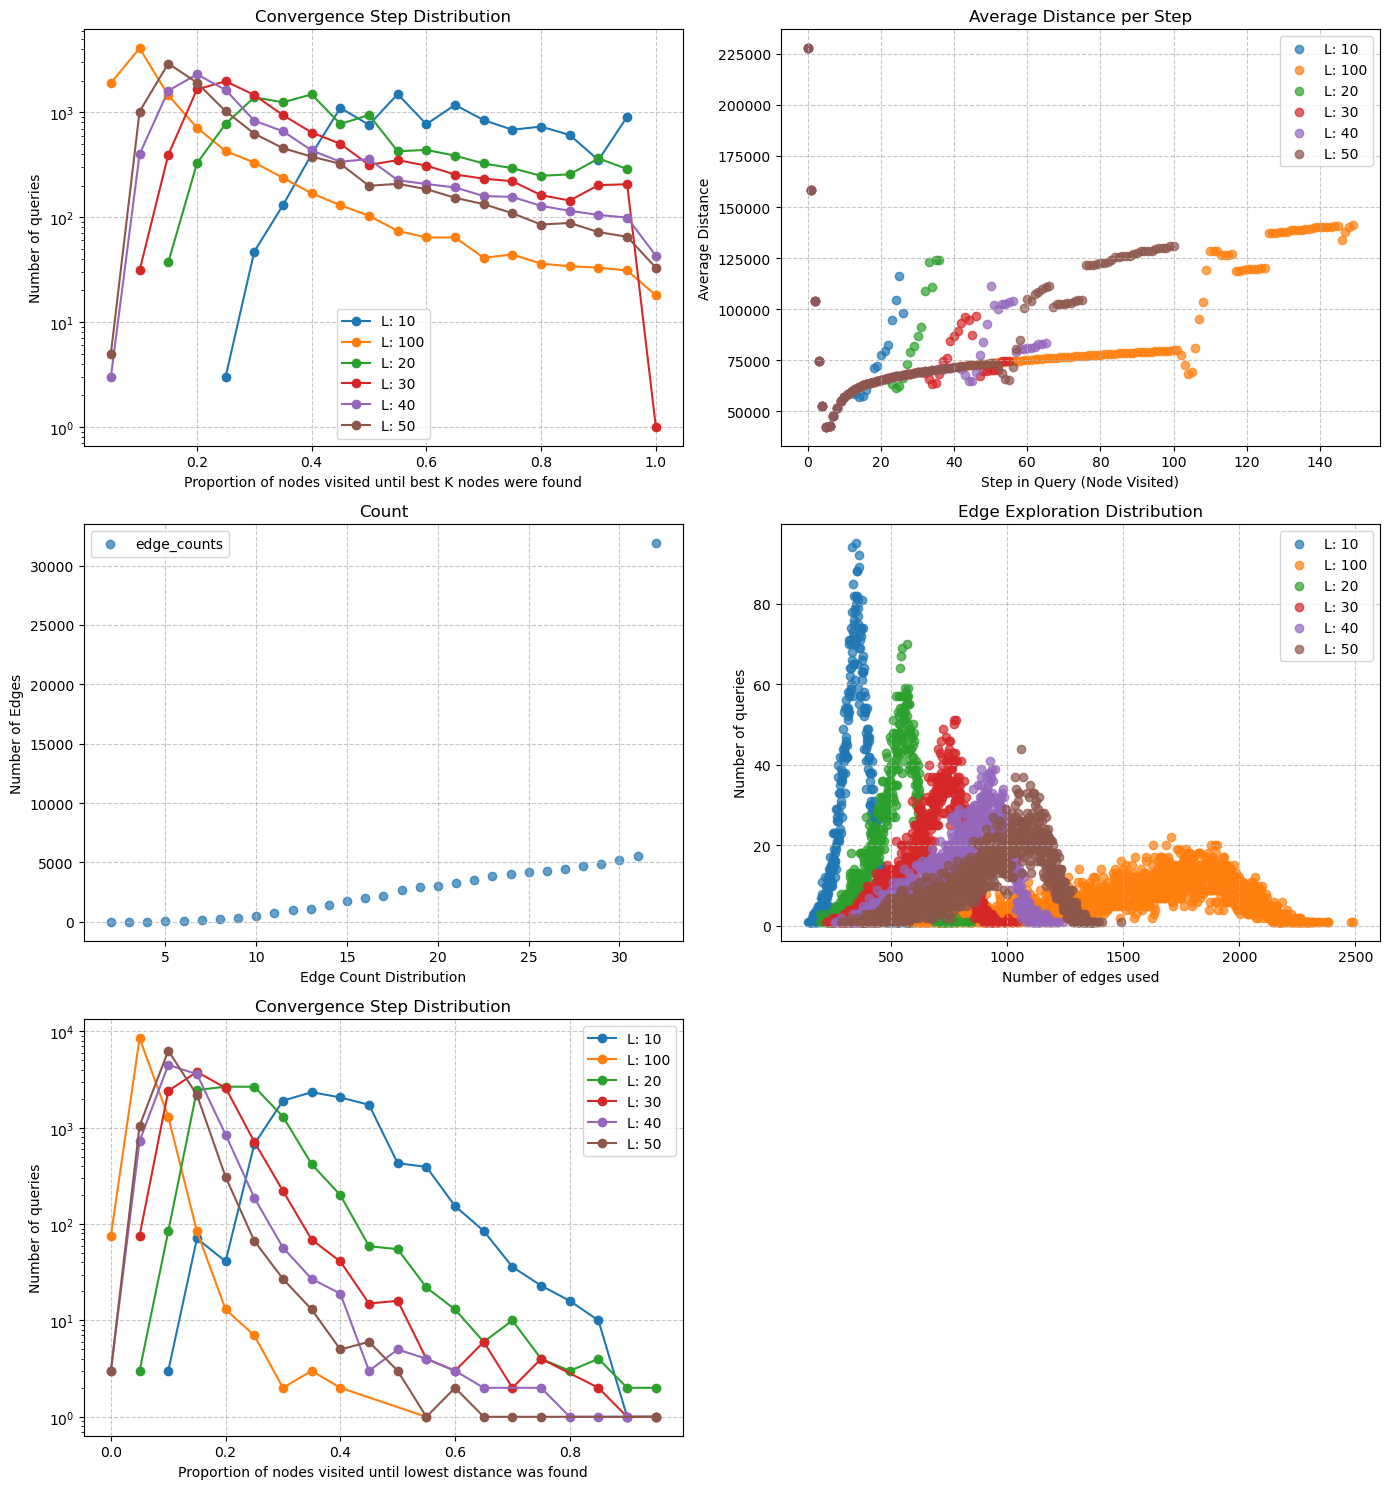

In [14]:

for experiment in experiments:
    ls = experiment["ls"]
    r = experiment["r"]
    l_build = experiment['l_build']
    alpha = experiment["alpha"]

    exp_id = f"r{r}-a{alpha}"

    experiment_folder = os.path.join(sift_folder, exp_id)
    os.makedirs(os.path.join(sift_folder, exp_id), exist_ok=True)

    index_prefix = os.path.join(experiment_folder, f"index_{base_file_name.replace(".fbin",'')}_R{str(r)}_L{str(l_build)}_A{str(alpha)}")
    result_path = os.path.join(experiment_folder,"res")

    for i in range(len(ls)):
        if int(ls[i]) > gt_k:
            raise ValueError("L should be less than or equal to ground truth K")
        ls[i] = str(ls[i])


    # Step 2: Build memory index
    cmd2 = [
        build_memory_index,
        "--data_type", "float",
        "--dist_fn", "l2",
        "--data_path", base_file,
        "--index_path_prefix", index_prefix,
        "-R", str(r),
        "-L", str(l_build),
        "--alpha", str(alpha)
    ]

    result = subprocess.run(
        cmd2,
        stdout=None if print_out else subprocess.DEVNULL,
        stderr=None if print_out else subprocess.DEVNULL,
        text=True
    )
    if result.returncode != 0:
        print(f"Error building index: {result.stderr}")
        exit(1)

    # Step 3: Search memory index
    cmd3 = [
        search_memory_index,
        "--data_type", "float",
        "--dist_fn", "l2",
        "--index_path_prefix", index_prefix,
        "--query_file", query_file,
        "--gt_file", gt_file,
        "-K", "10",
        "-L", *ls,
        "--result_path", result_path,
        "--num_threads", "1"
    ]

    results, nodes, out_edges = run_and_parse_output(cmd3, print_out=print_out)

    max_edges = nodes * r

    edges_used = (out_edges/max_edges) * 100


    print(f"\n\nAlpha: {alpha}, R: {r}")
    print(f"All steps completed successfully. {edges_used: >5.3f}% edges used")
    for result in results:
        print(f"{result[1]: >10.2f} QPS, for L : {result[0]}")

    if tracking:
        run_data_extractor(experiment_folder, apps_dir)
        plot_graphs(experiment_folder, 'res')